# Eigenfaces: PCA from Scratch

We implement PCA step by step with NumPy. Scikit-learn is used only to download the Olivetti Faces dataset.

## Step 1: Load and Inspect the Data

First, we load the images and labels and check their shapes.

In [27]:
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_olivetti_faces

figures_dir = Path("outputs/figures")
figures_dir.mkdir(parents=True, exist_ok=True)

In [28]:
faces = fetch_olivetti_faces()
images = faces.images
labels = faces.target

print("images shape:", images.shape)
print("flattened data shape:", faces.data.shape)
print("labels shape:", labels.shape)
print("number of people:", len(np.unique(labels)))
print("images for each person:", np.bincount(labels))

images shape: (400, 64, 64)
flattened data shape: (400, 4096)
labels shape: (400,)
number of people: 40
images for each person: [10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10
 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10 10]


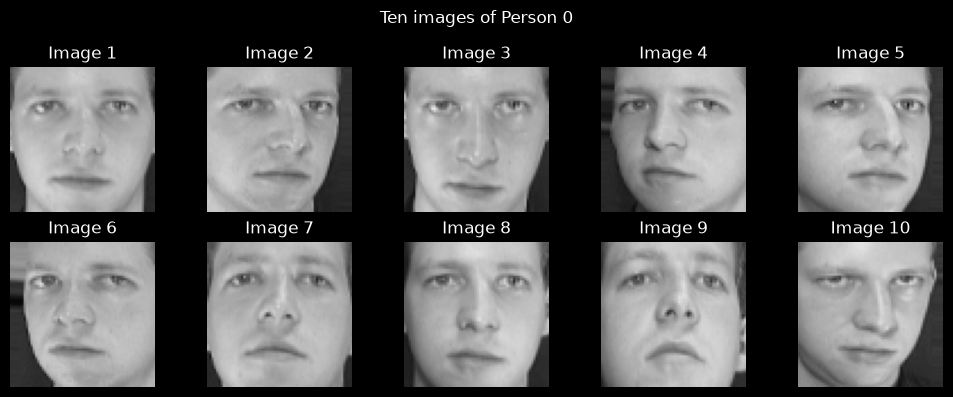

In [38]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(10):
    axes.flat[i].imshow(images[i], cmap="gray", vmin=0, vmax=1)
    axes.flat[i].set_title(f"Image {i + 1}")
    axes.flat[i].axis("off")

fig.suptitle("Ten images of Person 0")
plt.tight_layout()
fig.savefig(figures_dir / "person_zero_variations.png", dpi=150, bbox_inches="tight")
plt.show()

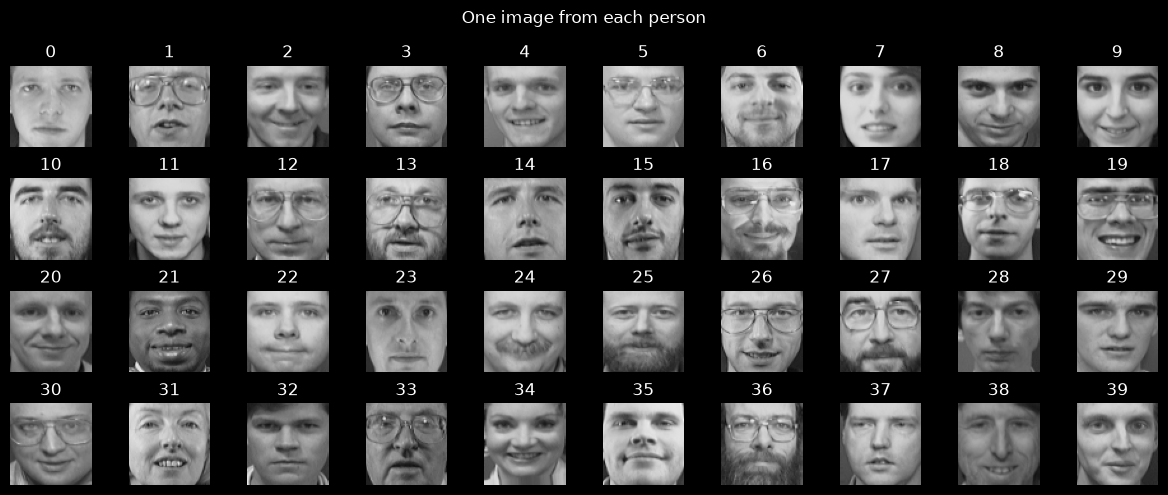

In [4]:
fig, axes = plt.subplots(4, 10, figsize=(12, 5))

for person in range(40):
    image_index = person * 10
    ax = axes[person // 10, person % 10]
    ax.imshow(images[image_index], cmap="gray", vmin=0, vmax=1)
    ax.set_title(f"{person}")
    ax.axis("off")

fig.suptitle("One image from each person")
plt.tight_layout()
fig.savefig(figures_dir / "sample_faces.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 2: Split the Training and Test Data

We use 8 training images and 2 test images for each person. A fixed random seed makes the split reproducible.

In [30]:
rng = np.random.default_rng(42)

train_indices = []
test_indices = []

for person in np.unique(labels):
    person_indices = np.where(labels == person)[0]
    shuffled_indices = rng.permutation(person_indices)

    train_indices.extend(shuffled_indices[:8])
    test_indices.extend(shuffled_indices[8:])

train_indices = np.array(train_indices)
test_indices = np.array(test_indices)

train_images = images[train_indices]
test_images = images[test_indices]
y_train = labels[train_indices]
y_test = labels[test_indices]

print("train images:", train_images.shape)
print("test images:", test_images.shape)

train images: (320, 64, 64)
test images: (80, 64, 64)


In [31]:
assert train_images.shape[0] == 320
assert test_images.shape[0] == 80
assert np.all(np.bincount(y_train) == 8)
assert np.all(np.bincount(y_test) == 2)
assert len(np.intersect1d(train_indices, test_indices)) == 0

print("split checks passed")

split checks passed


## Step 3: Convert Images to Vectors

Each 64 x 64 image becomes one row with 4096 pixel features.

In [7]:
X_train = train_images.reshape(len(train_images), -1).astype(np.float64)
X_test = test_images.reshape(len(test_images), -1).astype(np.float64)

assert X_train.shape == (320, 4096)
assert X_test.shape == (80, 4096)
assert X_train.dtype == np.float64

print("X_train shape:", X_train.shape)
print("X_test shape:", X_test.shape)

X_train shape: (320, 4096)
X_test shape: (80, 4096)


## Step 4: Mean Face and Centering

The mean face is calculated only from training data to prevent data leakage. The same training mean is subtracted from both training and test images.

```text
mean_face = sum of training faces / number of training faces
```

In [32]:
n_train = X_train.shape[0]

mean_face = np.sum(X_train, axis=0) / n_train
X_train_centered = X_train - mean_face
X_test_centered = X_test - mean_face

assert np.allclose(X_train_centered.mean(axis=0), 0, atol=1e-12)

print("mean face shape:", mean_face.shape)
print("largest centering error:", np.abs(X_train_centered.mean(axis=0)).max())

mean face shape: (4096,)
largest centering error: 2.251671071817896e-16


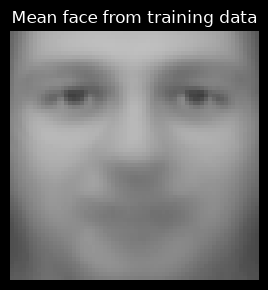

In [33]:
fig, ax = plt.subplots(figsize=(3, 3))
ax.imshow(mean_face.reshape(64, 64), cmap="gray", vmin=0, vmax=1)
ax.set_title("Mean face from training data")
ax.axis("off")

plt.tight_layout()
fig.savefig(figures_dir / "mean_face.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 5: Learn PCA with the Gram Matrix

The pixel covariance matrix would be 4096 x 4096. Because we have fewer training images than pixels, we solve the smaller 320 x 320 Gram matrix instead.

```text
Gram = (X_train_centered @ X_train_centered.T) / (n_train - 1)
```

In [10]:
gram_matrix = (
    X_train_centered @ X_train_centered.T
) / (n_train - 1)

total_variance = np.sum(X_train_centered ** 2) / (n_train - 1)

assert gram_matrix.shape == (320, 320)
assert np.allclose(gram_matrix, gram_matrix.T, atol=1e-12)

print("Gram matrix shape:", gram_matrix.shape)
print("total variance:", round(total_variance, 4))

Gram matrix shape: (320, 320)
total variance: 79.4179


In [11]:
eigenvalues, gram_eigenvectors = np.linalg.eigh(gram_matrix)

order = np.argsort(eigenvalues)[::-1]
eigenvalues = eigenvalues[order]
gram_eigenvectors = gram_eigenvectors[:, order]

useful = eigenvalues > eigenvalues[0] * 1e-10
eigenvalues = eigenvalues[useful]
gram_eigenvectors = gram_eigenvectors[:, useful]

assert np.all(np.diff(eigenvalues) <= 0)

print("number of useful components:", len(eigenvalues))
print("first 10 eigenvalues:")
print(np.round(eigenvalues[:10], 4))

number of useful components: 319
first 10 eigenvalues:
[18.9296 11.6741  6.1354  3.8166  2.8252  2.5447  1.9134  1.6315  1.6082
  1.303 ]


## Step 6: Build and Display the Eigenfaces

We map the Gram eigenvectors back to the 4096-pixel space and normalize them. Each resulting direction is an Eigenface.

In [12]:
eigenfaces = X_train_centered.T @ gram_eigenvectors
lengths = np.sqrt(np.sum(eigenfaces ** 2, axis=0))
eigenfaces = eigenfaces / lengths

identity = np.eye(eigenfaces.shape[1])

assert eigenfaces.shape == (4096, 319)
assert np.allclose(eigenfaces.T @ eigenfaces, identity, atol=1e-10)
assert np.allclose(np.sum(eigenvalues), total_variance)

print("eigenfaces shape:", eigenfaces.shape)
print("eigenfaces are orthonormal: True")
print("variance is preserved: True")

eigenfaces shape: (4096, 319)
eigenfaces are orthonormal: True
variance is preserved: True


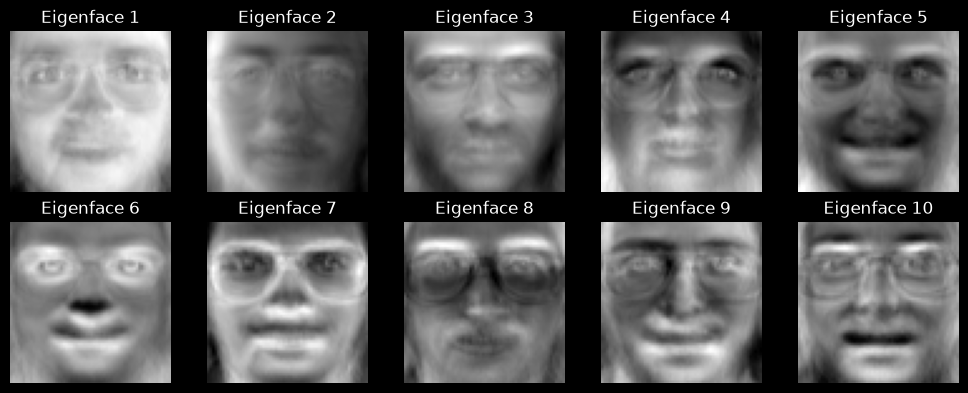

In [13]:
fig, axes = plt.subplots(2, 5, figsize=(10, 4))

for i in range(10):
    axes.flat[i].imshow(eigenfaces[:, i].reshape(64, 64), cmap="gray")
    axes.flat[i].set_title(f"Eigenface {i + 1}")
    axes.flat[i].axis("off")

plt.tight_layout()
fig.savefig(figures_dir / "top_eigenfaces.png", dpi=150, bbox_inches="tight")
plt.show()

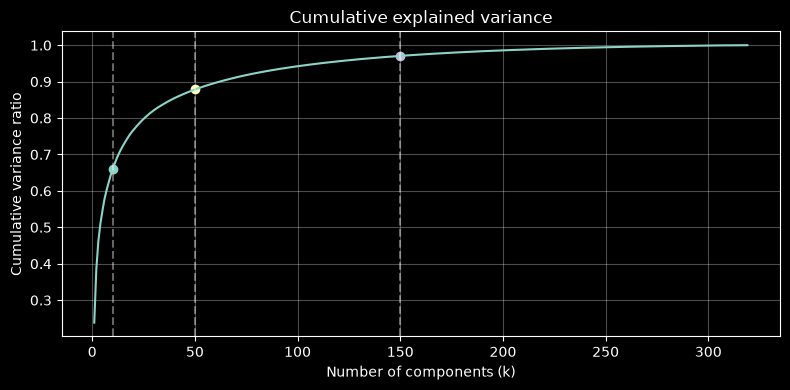

k=10: 65.96%
k=50: 87.85%
k=150: 97.06%


In [14]:
variance_ratio = eigenvalues / np.sum(eigenvalues)
cumulative_variance = np.cumsum(variance_ratio)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(range(1, len(cumulative_variance) + 1), cumulative_variance)

for k in [10, 50, 150]:
    ax.scatter(k, cumulative_variance[k - 1])
    ax.axvline(k, linestyle="--", alpha=0.4)

ax.set_title("Cumulative explained variance")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Cumulative variance ratio")
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(figures_dir / "cumulative_variance.png", dpi=150, bbox_inches="tight")
plt.show()

for k in [10, 50, 150]:
    print(f"k={k}: {cumulative_variance[k - 1] * 100:.2f}%")

## Step 7: Projection and Reconstruction

Each centered image is projected onto the first k Eigenfaces. With n images and k components, the compressed code has shape (n, k).

```text
codes = X_centered @ eigenfaces_k
reconstructed = codes @ eigenfaces_k.T + mean_face
```

In [15]:
required_k_values = [10, 50, 150]
comparison_k = 50

train_codes_by_k = {}
test_codes_by_k = {}
test_reconstructions_by_k = {}

for k in required_k_values:
    selected_eigenfaces = eigenfaces[:, :k]

    train_codes = X_train_centered @ selected_eigenfaces
    test_codes = X_test_centered @ selected_eigenfaces
    reconstructed_test = test_codes @ selected_eigenfaces.T + mean_face

    train_codes_by_k[k] = train_codes
    test_codes_by_k[k] = test_codes
    test_reconstructions_by_k[k] = reconstructed_test

    assert train_codes.shape == (320, k)
    assert test_codes.shape == (80, k)
    assert reconstructed_test.shape == (80, 4096)

print("projection and reconstruction shapes are correct")

projection and reconstruction shapes are correct


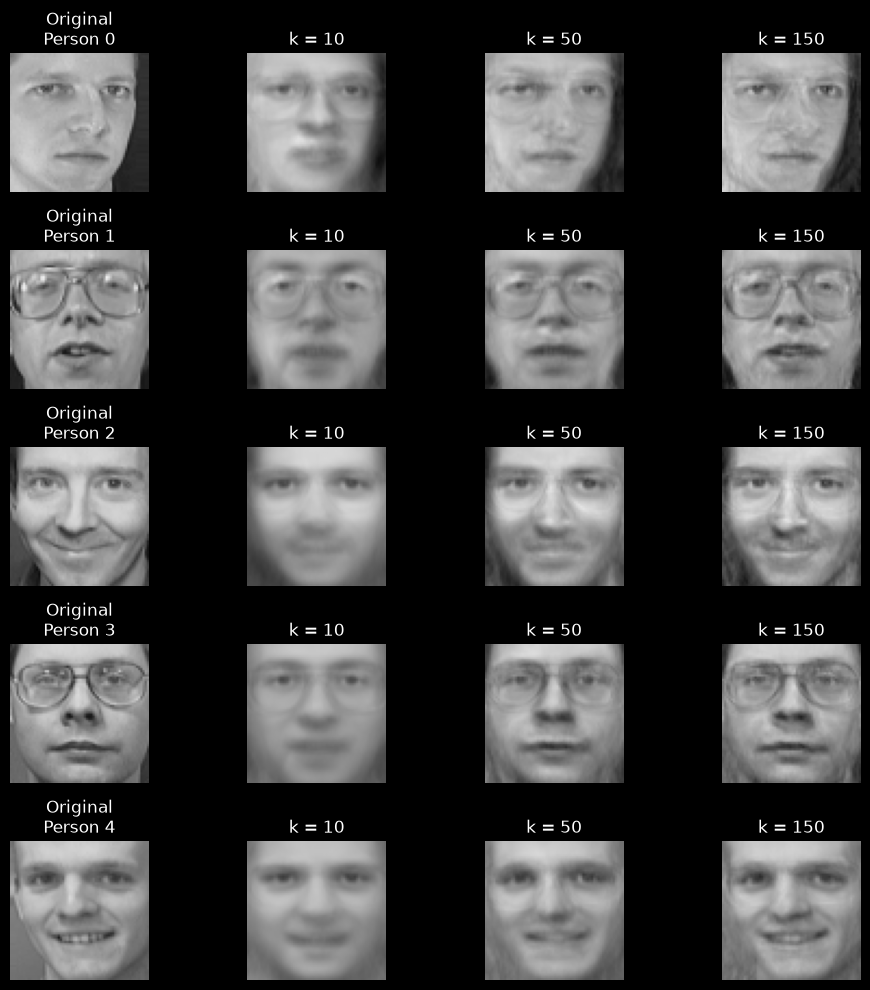

In [16]:
sample_indices = [0, 2, 4, 6, 8]
fig, axes = plt.subplots(5, 4, figsize=(10, 10))

for row, test_index in enumerate(sample_indices):
    axes[row, 0].imshow(
        X_test[test_index].reshape(64, 64),
        cmap="gray",
        vmin=0,
        vmax=1
    )
    axes[row, 0].set_title(f"Original\nPerson {y_test[test_index]}")
    axes[row, 0].axis("off")

    for column, k in enumerate(required_k_values):
        reconstructed = test_reconstructions_by_k[k][test_index]
        axes[row, column + 1].imshow(
            reconstructed.reshape(64, 64),
            cmap="gray",
            vmin=0,
            vmax=1
        )
        axes[row, column + 1].set_title(f"k = {k}")
        axes[row, column + 1].axis("off")

plt.tight_layout()
fig.savefig(figures_dir / "reconstruction_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Step 8: Reconstruction Error and Face Recognition

We measure reconstruction quality with MSE on test images. Then we implement 1-nearest-neighbor without a ready-made model.

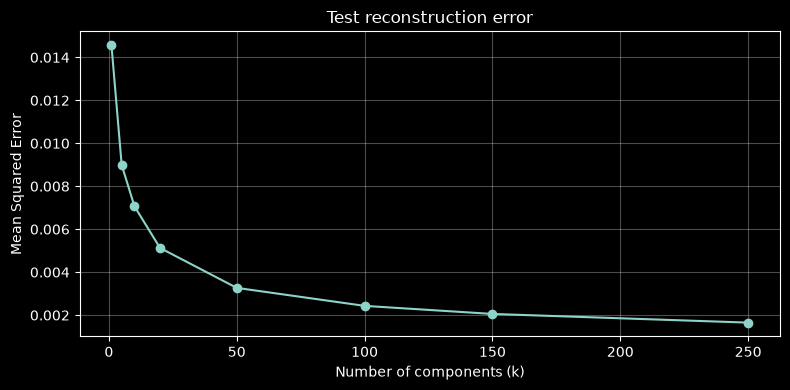

k=1: MSE=0.01456686
k=5: MSE=0.00899085
k=10: MSE=0.00706589
k=20: MSE=0.00512701
k=50: MSE=0.00326911
k=100: MSE=0.00243127
k=150: MSE=0.00205541
k=250: MSE=0.00165114


In [34]:
error_k_values = [1, 5, 10, 20, 50, 100, 150, 250]
reconstruction_errors = []

for k in error_k_values:
    selected_eigenfaces = eigenfaces[:, :k]
    test_codes = X_test_centered @ selected_eigenfaces
    reconstructed_test = test_codes @ selected_eigenfaces.T + mean_face

    mse = np.mean((X_test - reconstructed_test) ** 2)
    reconstruction_errors.append(mse)

assert np.all(np.diff(reconstruction_errors) <= 1e-12)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(error_k_values, reconstruction_errors, marker="o")
ax.set_title("Test reconstruction error")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Mean Squared Error")
ax.grid(alpha=0.3)

plt.tight_layout()
fig.savefig(figures_dir / "reconstruction_error.png", dpi=150, bbox_inches="tight")
plt.show()

for k, error in zip(error_k_values, reconstruction_errors):
    print(f"k={k}: MSE={error:.8f}")

### Nearest Neighbor from Scratch

Euclidean distance selects the smallest distance. Cosine similarity selects the largest similarity.

In [18]:
def nearest_neighbor_euclidean(train_codes, test_codes):
    matched_indices = []

    for test_code in test_codes:
        differences = train_codes - test_code
        distances = np.sqrt(np.sum(differences ** 2, axis=1))
        matched_indices.append(np.argmin(distances))

    return np.array(matched_indices)


def nearest_neighbor_cosine(train_codes, test_codes):
    matched_indices = []
    train_norms = np.sqrt(np.sum(train_codes ** 2, axis=1))

    for test_code in test_codes:
        test_norm = np.sqrt(np.sum(test_code ** 2))
        denominators = train_norms * test_norm
        denominators = np.maximum(denominators, 1e-12)

        similarities = (train_codes @ test_code) / denominators
        matched_indices.append(np.argmax(similarities))

    return np.array(matched_indices)

## Compare Euclidean Distance and Cosine Similarity

Both methods use the same split, Eigenfaces, and k values. Only the definition of similarity changes.

In [19]:
euclidean_accuracies = []
cosine_accuracies = []
euclidean_matches_by_k = {}
cosine_matches_by_k = {}

for k in required_k_values:
    train_codes = train_codes_by_k[k]
    test_codes = test_codes_by_k[k]

    euclidean_matches = nearest_neighbor_euclidean(train_codes, test_codes)
    cosine_matches = nearest_neighbor_cosine(train_codes, test_codes)

    euclidean_predictions = y_train[euclidean_matches]
    cosine_predictions = y_train[cosine_matches]

    euclidean_accuracy = np.mean(euclidean_predictions == y_test)
    cosine_accuracy = np.mean(cosine_predictions == y_test)

    euclidean_accuracies.append(euclidean_accuracy)
    cosine_accuracies.append(cosine_accuracy)
    euclidean_matches_by_k[k] = euclidean_matches
    cosine_matches_by_k[k] = cosine_matches

    print(
        f"k={k}: "
        f"Euclidean={euclidean_accuracy * 100:.2f}% | "
        f"Cosine={cosine_accuracy * 100:.2f}%"
    )

assert len(euclidean_accuracies) == 3
assert len(cosine_accuracies) == 3

k=10: Euclidean=92.50% | Cosine=87.50%
k=50: Euclidean=93.75% | Cosine=93.75%
k=150: Euclidean=93.75% | Cosine=93.75%


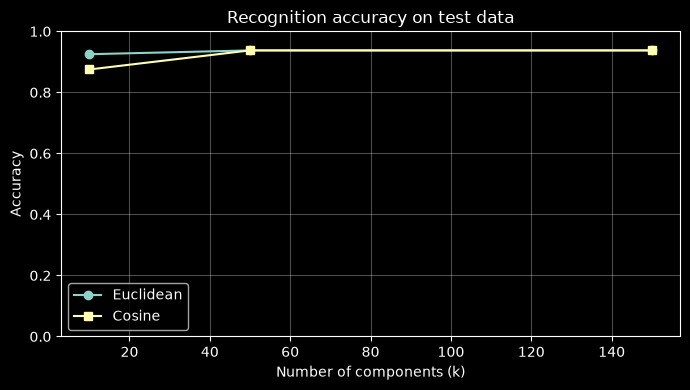

In [20]:
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(required_k_values, euclidean_accuracies, marker="o", label="Euclidean")
ax.plot(required_k_values, cosine_accuracies, marker="s", label="Cosine")
ax.set_title("Recognition accuracy on test data")
ax.set_xlabel("Number of components (k)")
ax.set_ylabel("Accuracy")
ax.set_ylim(0, 1)
ax.grid(alpha=0.3)
ax.legend()

plt.tight_layout()
fig.savefig(figures_dir / "metric_accuracy.png", dpi=150, bbox_inches="tight")
plt.show()

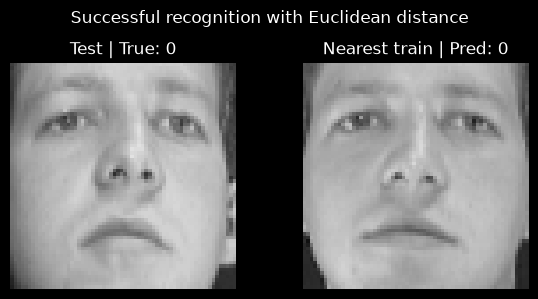

In [21]:
euclidean_matches = euclidean_matches_by_k[comparison_k]
euclidean_predictions = y_train[euclidean_matches]

correct_indices = np.where(euclidean_predictions == y_test)[0]
failure_indices = np.where(euclidean_predictions != y_test)[0]

success_index = correct_indices[0]
success_match = euclidean_matches[success_index]

fig, axes = plt.subplots(1, 2, figsize=(6, 3))
axes[0].imshow(X_test[success_index].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Test | True: {y_test[success_index]}")
axes[1].imshow(X_train[success_match].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Nearest train | Pred: {euclidean_predictions[success_index]}")

for ax in axes:
    ax.axis("off")

fig.suptitle("Successful recognition with Euclidean distance")
plt.tight_layout()
fig.savefig(figures_dir / "successful_example.png", dpi=150, bbox_inches="tight")
plt.show()

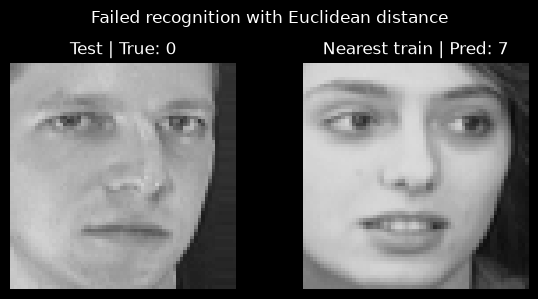

In [22]:
if len(failure_indices) > 0:
    failure_index = failure_indices[0]
    failure_match = euclidean_matches[failure_index]

    fig, axes = plt.subplots(1, 2, figsize=(6, 3))
    axes[0].imshow(X_test[failure_index].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
    axes[0].set_title(f"Test | True: {y_test[failure_index]}")
    axes[1].imshow(X_train[failure_match].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
    axes[1].set_title(f"Nearest train | Pred: {euclidean_predictions[failure_index]}")

    for ax in axes:
        ax.axis("off")

    fig.suptitle("Failed recognition with Euclidean distance")
    plt.tight_layout()
    fig.savefig(figures_dir / "failure_example.png", dpi=150, bbox_inches="tight")
    plt.show()
else:
    print("No failure was found for this setting.")

### Examples with Different Neighbors

For these visual examples, we use k = 50 as a fixed comparison point. This does not mean that k = 50 is always the best choice.

different neighbor count: 5
different prediction count: 1


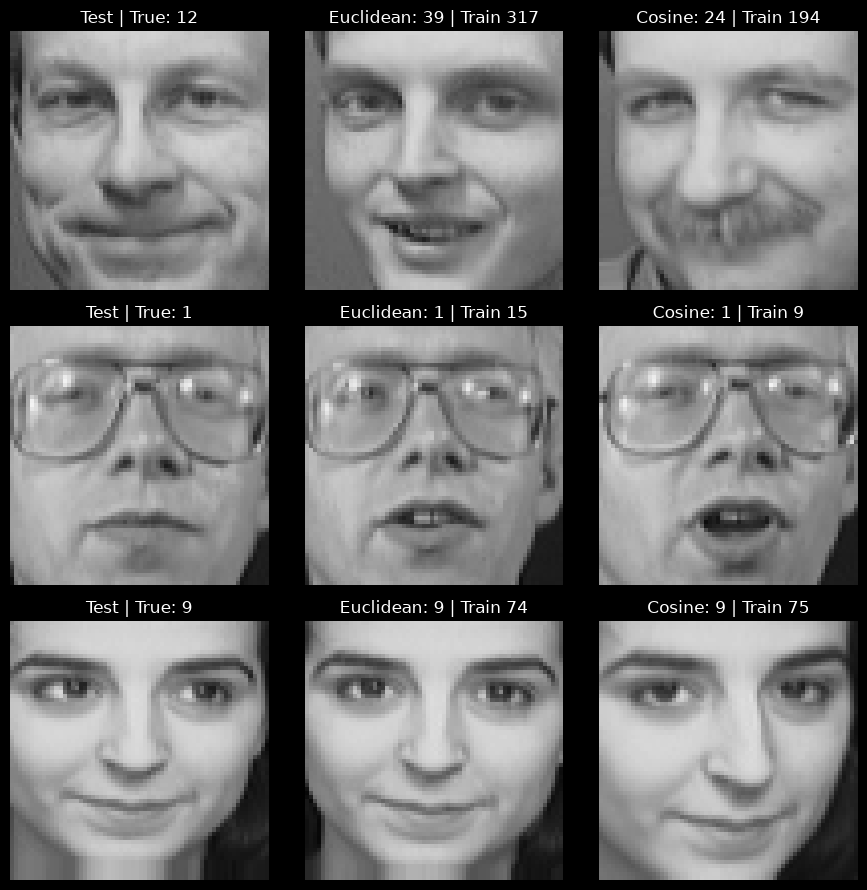

In [23]:
cosine_matches = cosine_matches_by_k[comparison_k]
different_neighbor_indices = np.where(euclidean_matches != cosine_matches)[0]
different_prediction_indices = np.where(
    y_train[euclidean_matches] != y_train[cosine_matches]
)[0]

other_neighbor_indices = np.setdiff1d(
    different_neighbor_indices,
    different_prediction_indices
)
display_indices = np.concatenate([
    different_prediction_indices,
    other_neighbor_indices
])

print("different neighbor count:", len(different_neighbor_indices))
print("different prediction count:", len(different_prediction_indices))

number_to_show = min(3, len(display_indices))

if number_to_show > 0:
    fig, axes = plt.subplots(number_to_show, 3, figsize=(9, 3 * number_to_show))

    if number_to_show == 1:
        axes = np.array([axes])

    for row in range(number_to_show):
        test_index = display_indices[row]
        euclidean_match = euclidean_matches[test_index]
        cosine_match = cosine_matches[test_index]

        axes[row, 0].imshow(X_test[test_index].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
        axes[row, 0].set_title(f"Test | True: {y_test[test_index]}")

        axes[row, 1].imshow(X_train[euclidean_match].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
        axes[row, 1].set_title(
            f"Euclidean: {y_train[euclidean_match]} | Train {euclidean_match}"
        )

        axes[row, 2].imshow(X_train[cosine_match].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
        axes[row, 2].set_title(
            f"Cosine: {y_train[cosine_match]} | Train {cosine_match}"
        )

        for column in range(3):
            axes[row, column].axis("off")

    plt.tight_layout()
    fig.savefig(figures_dir / "different_neighbors.png", dpi=150, bbox_inches="tight")
    plt.show()

## Step 9: Minimal Comparison with SVD

SVD is used only to validate the Gram PCA result. We compare eigenvalues and reconstructions, because eigenvector signs may be different.

In [24]:
_, singular_values, vt = np.linalg.svd(
    X_train_centered,
    full_matrices=False
)

svd_eigenvalues = singular_values ** 2 / (n_train - 1)
svd_eigenfaces = vt.T

first_values_match = np.allclose(
    eigenvalues[:10],
    svd_eigenvalues[:10]
)

svd_basis = svd_eigenfaces[:, :comparison_k]
svd_test_codes = X_test_centered @ svd_basis
svd_reconstruction = svd_test_codes @ svd_basis.T + mean_face

gram_reconstruction = test_reconstructions_by_k[comparison_k]
reconstruction_difference = np.mean(
    (gram_reconstruction - svd_reconstruction) ** 2
)

assert first_values_match
assert reconstruction_difference < 1e-20

print("first 10 eigenvalues match:", first_values_match)
print("MSE between Gram and SVD reconstructions:", reconstruction_difference)

first 10 eigenvalues match: True
MSE between Gram and SVD reconstructions: 4.737250068483667e-31


## Simple Interactive Demo

Change the three values below and run only the next cell. PCA does not need to be trained again.

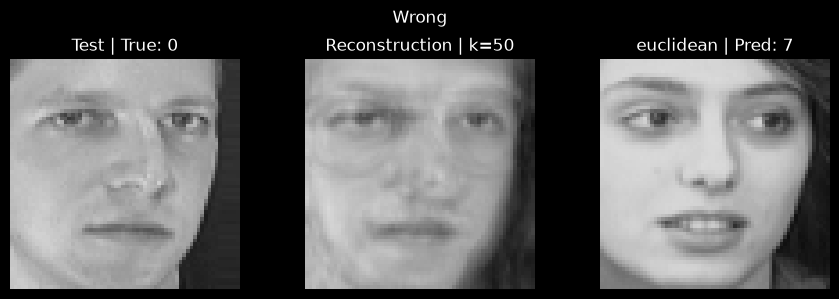

In [37]:
demo_test_index = 0
demo_k = 50
demo_metric = "euclidean"  # "euclidean" or "cosine"

assert 0 <= demo_test_index < len(X_test)
assert demo_k in required_k_values
assert demo_metric in ["euclidean", "cosine"]

demo_train_codes = train_codes_by_k[demo_k]
demo_test_codes = test_codes_by_k[demo_k]

if demo_metric == "euclidean":
    demo_matches = nearest_neighbor_euclidean(
        demo_train_codes,
        demo_test_codes[[demo_test_index]]
    )
else:
    demo_matches = nearest_neighbor_cosine(
        demo_train_codes,
        demo_test_codes[[demo_test_index]]
    )

demo_match = demo_matches[0]
demo_prediction = y_train[demo_match]
demo_reconstruction = test_reconstructions_by_k[demo_k][demo_test_index]

fig, axes = plt.subplots(1, 3, figsize=(9, 3))
axes[0].imshow(X_test[demo_test_index].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
axes[0].set_title(f"Test | True: {y_test[demo_test_index]}")
axes[1].imshow(demo_reconstruction.reshape(64, 64), cmap="gray", vmin=0, vmax=1)
axes[1].set_title(f"Reconstruction | k={demo_k}")
axes[2].imshow(X_train[demo_match].reshape(64, 64), cmap="gray", vmin=0, vmax=1)
axes[2].set_title(f"{demo_metric} | Pred: {demo_prediction}")

for ax in axes:
    ax.axis("off")

result = "Correct" if demo_prediction == y_test[demo_test_index] else "Wrong"
fig.suptitle(result)
plt.tight_layout()
fig.savefig(figures_dir / "demo_example.png", dpi=150, bbox_inches="tight")
plt.show()

## Final Checks

These assertions check the main shapes, centering, eigenvalue order, orthonormal Eigenfaces, reconstruction error, and prediction outputs.

In [26]:
assert X_train.shape == (320, 4096)
assert X_test.shape == (80, 4096)
assert np.allclose(X_train_centered.mean(axis=0), 0, atol=1e-12)
assert np.allclose(gram_matrix, gram_matrix.T, atol=1e-12)
assert np.all(np.diff(eigenvalues) <= 0)
assert np.allclose(eigenfaces.T @ eigenfaces, identity, atol=1e-10)
assert np.all(np.diff(reconstruction_errors) <= 1e-12)
assert euclidean_predictions.shape == y_test.shape
assert cosine_predictions.shape == y_test.shape

print("all final checks passed")

all final checks passed


## Conclusion and limitations

- Increasing k reduced the reconstruction error.
- Euclidean distance and Cosine similarity did not always select the same neighbor.
- Neither metric is always better; the result depends on the data and the number of components.
- Our result is limited to the Olivetti Faces dataset, random seed 42, and the tested k values.